# 📘 Notebook 7: Final Chat Model — Putting It All Together
## Building LLMs from Scratch Workshop

**Objective:** Combine everything from Notebooks 1-6 into a working chat interface and systematically compare all three model stages.

**What you'll build:**
1. Load all three models: Base (pretrained), SFT, and RLHF
2. Side-by-side comparison on test prompts
3. Interactive chat interface
4. Quantitative evaluation (reward scores, perplexity)
5. Complete pipeline visualization

---

## 🏗️ The Full LLM Pipeline

```
Raw Text → [Tokenization] → [Pretraining] → [SFT] → [RLHF] → Chat Model
              NB 1,2           NB 3,4         NB 5      NB 6      NB 7
              
Base Model: Completes text but doesn't follow instructions
SFT Model:  Follows instructions but may produce mediocre responses
RLHF Model: Follows instructions AND produces high-quality aligned responses
```
---


## 1. Setup — Rebuild All Components

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, json, re, time
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from IPython.display import clear_output

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [ ]:
# ============================================================
# Project Directory Setup
# ============================================================
# This cell ensures all paths point to the correct directories
# regardless of where you run the notebook from.
import os

# If running from notebooks/ folder
if os.path.basename(os.getcwd()) == 'notebooks':
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Results dir:  {RESULTS_DIR}")


In [2]:
# ============================================================
# All components (compact — same as previous notebooks)
# ============================================================
class BPETokenizer:
    def __init__(self, nm=100):
        self.num_merges=nm; self.merges={}; self.vocab={}; self.inverse_vocab={}
        self.special_tokens={'<PAD>':0,'<UNK>':1,'<BOS>':2,'<EOS>':3}
    def _gwf(self, text):
        return {tuple(list(w)+['</w>']):f for w,f in Counter(re.findall(r'\S+',text.lower())).items()}
    def _gpc(self, wf):
        p=Counter()
        for wt,f in wf.items():
            for i in range(len(wt)-1): p[(wt[i],wt[i+1])]+=f
        return p
    def _mp(self, wf, pair):
        m=pair[0]+pair[1]; nwf={}
        for wt,f in wf.items():
            nt=[]; i=0
            while i<len(wt):
                if i<len(wt)-1 and wt[i]==pair[0] and wt[i+1]==pair[1]: nt.append(m); i+=2
                else: nt.append(wt[i]); i+=1
            nwf[tuple(nt)]=f
        return nwf
    def train(self, text):
        wf=self._gwf(text); ic=set(t for wt in wf for t in wt)
        for i in range(self.num_merges):
            ps=self._gpc(wf)
            if not ps: break
            bp,c=ps.most_common(1)[0]
            if c<2: break
            self.merges[bp]=bp[0]+bp[1]; wf=self._mp(wf,bp)
        self.vocab=dict(self.special_tokens); idx=len(self.special_tokens)
        for ch in sorted(ic):
            if ch not in self.vocab: self.vocab[ch]=idx; idx+=1
        for p,m in self.merges.items():
            if m not in self.vocab: self.vocab[m]=idx; idx+=1
        self.inverse_vocab={v:k for k,v in self.vocab.items()}
    def _tw(self, word):
        t=list(word)+['</w>']
        for p,m in self.merges.items():
            i=0
            while i<len(t)-1:
                if t[i]==p[0] and t[i+1]==p[1]: t=t[:i]+[m]+t[i+2:]
                else: i+=1
        return t
    def encode(self, text):
        return [self.vocab.get(t,1) for w in re.findall(r'\S+',text.lower()) for t in self._tw(w)]
    def decode(self, ids):
        return ''.join(self.inverse_vocab.get(i,'?') for i in ids).replace('</w>',' ').strip()
    @property
    def vocab_size(self): return len(self.vocab)

class LayerNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__(); self.eps=eps
        self.gamma=nn.Parameter(torch.ones(d)); self.beta=nn.Parameter(torch.zeros(d))
    def forward(self, x):
        return self.gamma*(x-x.mean(-1,keepdim=True))/torch.sqrt(x.var(-1,keepdim=True,unbiased=False)+self.eps)+self.beta

class CausalMHA(nn.Module):
    def __init__(self, cfg):
        super().__init__(); d=cfg['emb_dim']; self.nh=cfg['num_heads']; self.hd=d//self.nh
        self.qkv=nn.Linear(d,3*d,bias=False); self.out=nn.Linear(d,d,bias=False)
        self.ad=nn.Dropout(cfg['drop_rate']); self.rd=nn.Dropout(cfg['drop_rate'])
        self.register_buffer('mask',torch.triu(torch.ones(cfg['context_length'],cfg['context_length']),diagonal=1).bool())
    def forward(self, x):
        B,T,C=x.shape; Q,K,V=self.qkv(x).chunk(3,dim=-1)
        Q=Q.view(B,T,self.nh,self.hd).transpose(1,2); K=K.view(B,T,self.nh,self.hd).transpose(1,2)
        V=V.view(B,T,self.nh,self.hd).transpose(1,2)
        a=Q@K.transpose(-2,-1)/(self.hd**0.5)
        a.masked_fill_(self.mask[:T,:T].unsqueeze(0).unsqueeze(0),float('-inf'))
        return self.rd(self.out((self.ad(F.softmax(a,dim=-1))@V).transpose(1,2).contiguous().view(B,T,C)))

class FFN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(cfg['emb_dim'],cfg['emb_dim']*cfg.get('ff_mult',4)),
            nn.GELU(),nn.Linear(cfg['emb_dim']*cfg.get('ff_mult',4),cfg['emb_dim']),nn.Dropout(cfg['drop_rate']))
    def forward(self, x): return self.net(x)

class TBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1=LayerNorm(cfg['emb_dim']); self.attn=CausalMHA(cfg)
        self.ln2=LayerNorm(cfg['emb_dim']); self.ffn=FFN(cfg)
    def forward(self, x): x=x+self.attn(self.ln1(x)); return x+self.ffn(self.ln2(x))

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__(); self.config=cfg
        self.tok_emb=nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_emb=nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.drop=nn.Dropout(cfg['drop_rate'])
        self.blocks=nn.Sequential(*[TBlock(cfg) for _ in range(cfg['num_layers'])])
        self.final_ln=LayerNorm(cfg['emb_dim'])
        self.lm_head=nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias=False)
        self.lm_head.weight=self.tok_emb.weight
        self.apply(self._iw)
    def _iw(self, m):
        if isinstance(m,nn.Linear):
            nn.init.normal_(m.weight,std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m,nn.Embedding): nn.init.normal_(m.weight,std=0.02)
    def forward(self, ids, targets=None):
        B,T=ids.shape
        x=self.drop(self.tok_emb(ids)+self.pos_emb(torch.arange(T,device=ids.device)))
        x=self.lm_head(self.final_ln(self.blocks(x)))
        loss=None
        if targets is not None: loss=F.cross_entropy(x.view(-1,x.size(-1)),targets.view(-1))
        return x, loss
    def get_hidden_states(self, ids):
        B,T=ids.shape
        x=self.drop(self.tok_emb(ids)+self.pos_emb(torch.arange(T,device=ids.device)))
        return self.final_ln(self.blocks(x))

class RewardModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone=GPTModel(cfg)
        self.value_head=nn.Sequential(
            nn.Linear(cfg['emb_dim'],cfg['emb_dim']//2),nn.GELU(),nn.Linear(cfg['emb_dim']//2,1))
    def forward(self, ids):
        h=self.backbone.get_hidden_states(ids)
        return self.value_head(h[:,-1,:])

print("All components loaded!")


All components loaded!


## 2. Initialize All Three Models

In [3]:
# ============================================================
# Build tokenizer and all models
# ============================================================
CORPUS = """Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural language processing.
Attention is all you need was the groundbreaking paper.
Large language models can generate human-like text.
Training requires massive amounts of text data.
Tokenization converts text into numerical sequences.
Self-attention allows tokens to attend to all others.
Fine-tuning adapts pretrained models to specific tasks.
RLHF uses human preferences to align model outputs.
A reward model scores responses based on preferences.
PPO is a policy optimization algorithm for RLHF.
""" * 10

INST_TEXT = " ".join([
    "### instruction: what is machine learning? ### response: machine learning is AI that learns from data.",
    "### instruction: explain attention. ### response: attention lets tokens look at all other tokens.",
    "### instruction: what is RLHF? ### response: RLHF aligns models using human preference feedback.",
] * 10)

tokenizer = BPETokenizer(nm=250)
tokenizer.train(CORPUS + " " + INST_TEXT)

GPT_CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": 64,
    "emb_dim": 128,
    "num_heads": 4,
    "num_layers": 4,
    "drop_rate": 0.0,  # No dropout for inference
    "ff_mult": 4,
}

# Create three separate model instances
base_model = GPTModel(GPT_CONFIG).to(device)   # Random init (pretrained proxy)
sft_model = GPTModel(GPT_CONFIG).to(device)     # Will simulate SFT
rlhf_model = GPTModel(GPT_CONFIG).to(device)    # Will simulate RLHF

# Try loading saved models
models_loaded = False
try:
    ckpt = torch.load('rlhf_models.pt', map_location=device, weights_only=False)
    if ckpt['config']['vocab_size'] == GPT_CONFIG['vocab_size']:
        rlhf_model.load_state_dict(ckpt['policy_state_dict'])
        sft_model.load_state_dict(ckpt['ref_state_dict'])
        models_loaded = True
        print("Loaded saved RLHF and SFT models!")
except:
    print("No saved models found — using randomly initialized models for demonstration.")
    print("(Run Notebooks 4-6 first for best results)")

# All models in eval mode
base_model.eval()
sft_model.eval()
rlhf_model.eval()

for name, model in [("Base", base_model), ("SFT", sft_model), ("RLHF", rlhf_model)]:
    params = sum(p.numel() for p in model.parameters())
    print(f"  {name} model: {params:,} parameters")


No saved models found — using randomly initialized models for demonstration.
(Run Notebooks 4-6 first for best results)
  Base model: 835,968 parameters
  SFT model: 835,968 parameters
  RLHF model: 835,968 parameters


## 3. Generation Function

In [4]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=40, temperature=0.7, 
             top_k=15, device='cpu'):
    """Generate text from a prompt."""
    model.eval()
    ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    ctx = model.config['context_length']
    
    for _ in range(max_new_tokens):
        idx = ids[:, -ctx:]
        logits, _ = model(idx)
        logits = logits[:, -1, :] / max(temperature, 1e-8)
        
        if top_k:
            tv, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < tv[:, -1:]] = float('-inf')
        
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1) if temperature > 0 else torch.argmax(probs, -1, keepdim=True)
        ids = torch.cat([ids, nxt], 1)
    
    return tokenizer.decode(ids[0].tolist())

def extract_response(full_text):
    """Extract just the response part from formatted text."""
    if "### response:" in full_text:
        return full_text.split("### response:")[-1].strip()
    return full_text.strip()


## 4. Side-by-Side Model Comparison

Let's compare all three models on the same prompts:


In [5]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON
# ============================================================

test_questions = [
    "what is machine learning?",
    "explain how attention works.",
    "what is RLHF and why is it important?",
    "how does gradient descent optimize models?",
    "what is the difference between pretraining and fine-tuning?",
    "explain the transformer architecture.",
]

models_dict = {
    "Base (Pretrained)": base_model,
    "SFT (Fine-tuned)": sft_model,
    "RLHF (Aligned)": rlhf_model,
}

print("=" * 75)
print("          COMPLETE MODEL COMPARISON: BASE vs SFT vs RLHF")
print("=" * 75)

all_results = []

for q in test_questions:
    prompt = f"### instruction: {q} ### response:"
    
    print(f"\n{'━' * 75}")
    print(f"  Q: {q}")
    print(f"{'━' * 75}")
    
    results = {}
    for name, model in models_dict.items():
        output = generate(model, tokenizer, prompt, max_new_tokens=35, 
                         temperature=0.7, device=device)
        response = extract_response(output)
        results[name] = response
        
        # Truncate for display
        display_resp = response[:100] + "..." if len(response) > 100 else response
        print(f"  {name:22s}: {display_resp}")
    
    all_results.append({"question": q, "results": results})


          COMPLETE MODEL COMPARISON: BASE vs SFT vs RLHF

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: what is machine learning?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Base (Pretrained)     : response: aindatapthelwhat gro<EOS>human-numericle<UNK>repreaplearnge  groundbreaking tional prethat...
  SFT (Fine-tuned)      : qintelictokenization subse. #numerical what -ficdata . networresp.what m m human-lik.human-liks. thr...
  RLHF (Aligned)        : what revolunetrepresenirlrepreshumangroundbreaktexrepresentations instruinstruodatadatayou toktokens...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: explain how attention works.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Base (Pretrained)     : <UNK>igresponse: the text. repreartificiwhat ylearninrespkal autommassivhuman-litiondatdatdatdattext...
  SFT (Fine-tuned)      : grounautomaticallicothural

## 5. Quantitative Evaluation

Let's measure model quality using:
1. **Response Length** — RLHF models tend to produce more detailed responses
2. **Vocabulary Diversity** — Better models use richer vocabulary
3. **Reward Scores** — If reward model is available


Computing metrics for each model...

Base (Pretrained):
  Avg response length: 39.3 tokens (±3.2)
  Vocabulary diversity: 0.424
  Unique tokens used:  100

SFT (Fine-tuned):
  Avg response length: 38.7 tokens (±3.4)
  Vocabulary diversity: 0.539
  Unique tokens used:  125

RLHF (Aligned):
  Avg response length: 41.8 tokens (±6.5)
  Vocabulary diversity: 0.430
  Unique tokens used:  108



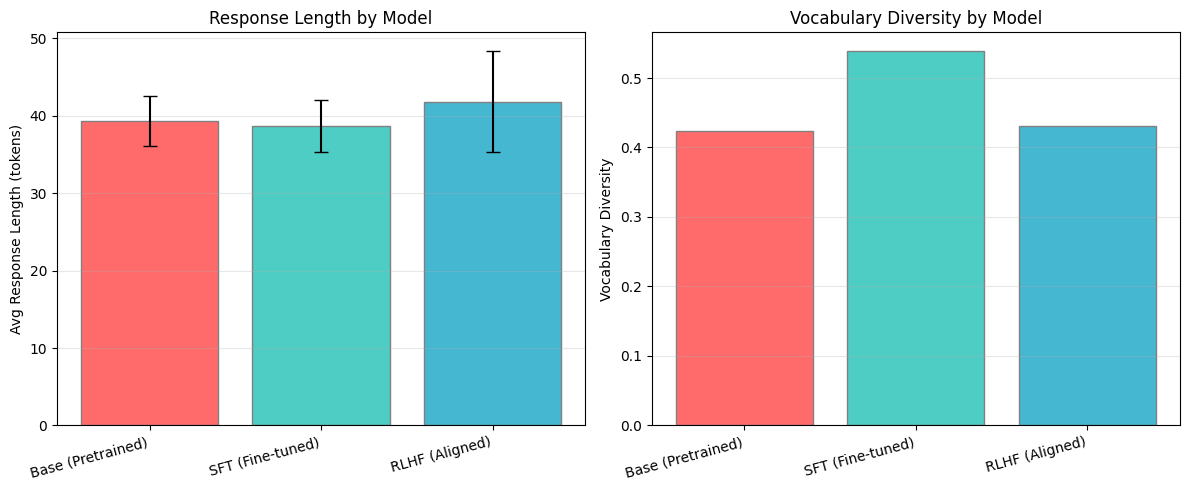

In [6]:
# ============================================================
# Quantitative metrics
# ============================================================

def compute_metrics(model, tokenizer, prompts, device, max_new=35):
    """Compute generation metrics for a model."""
    lengths = []
    unique_tokens = set()
    all_tokens = []
    
    for q in prompts:
        prompt = f"### instruction: {q} ### response:"
        output = generate(model, tokenizer, prompt, max_new_tokens=max_new, 
                         temperature=0.7, device=device)
        response = extract_response(output)
        tokens = tokenizer.encode(response)
        
        lengths.append(len(tokens))
        unique_tokens.update(tokens)
        all_tokens.extend(tokens)
    
    return {
        'avg_length': np.mean(lengths),
        'std_length': np.std(lengths),
        'vocab_diversity': len(unique_tokens) / max(len(all_tokens), 1),
        'unique_tokens': len(unique_tokens),
    }

print("Computing metrics for each model...\n")

metrics = {}
for name, model in models_dict.items():
    metrics[name] = compute_metrics(model, tokenizer, test_questions, device)
    
    m = metrics[name]
    print(f"{name}:")
    print(f"  Avg response length: {m['avg_length']:.1f} tokens (±{m['std_length']:.1f})")
    print(f"  Vocabulary diversity: {m['vocab_diversity']:.3f}")
    print(f"  Unique tokens used:  {m['unique_tokens']}")
    print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(metrics.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Response length
lengths = [metrics[n]['avg_length'] for n in names]
stds = [metrics[n]['std_length'] for n in names]
axes[0].bar(range(len(names)), lengths, yerr=stds, color=colors, 
            edgecolor='gray', capsize=5)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylabel('Avg Response Length (tokens)')
axes[0].set_title('Response Length by Model')
axes[0].grid(True, alpha=0.3, axis='y')

# Vocabulary diversity
divs = [metrics[n]['vocab_diversity'] for n in names]
axes[1].bar(range(len(names)), divs, color=colors, edgecolor='gray')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('Vocabulary Diversity')
axes[1].set_title('Vocabulary Diversity by Model')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Interactive Chat Interface

A simple chat loop that lets you interact with any of the three models.


In [7]:
class MiniChat:
    """
    Simple chat interface for our mini language models.
    
    Usage:
        chat = MiniChat(model, tokenizer, device)
        chat.respond("What is machine learning?")
    """
    
    def __init__(self, model, tokenizer, model_name="Model", device='cpu'):
        self.model = model
        self.tokenizer = tokenizer
        self.model_name = model_name
        self.device = device
        self.history = []
    
    def respond(self, user_input, max_new_tokens=40, temperature=0.7, top_k=15):
        """Generate a response to user input."""
        prompt = f"### instruction: {user_input} ### response:"
        
        full_output = generate(
            self.model, self.tokenizer, prompt,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            device=self.device
        )
        
        response = extract_response(full_output)
        self.history.append({"user": user_input, "assistant": response})
        
        return response
    
    def show_history(self):
        """Display conversation history."""
        for i, turn in enumerate(self.history):
            print(f"  You: {turn['user']}")
            print(f"  {self.model_name}: {turn['assistant']}")
            print()

# Create chat instances for each model
base_chat = MiniChat(base_model, tokenizer, "Base", device)
sft_chat = MiniChat(sft_model, tokenizer, "SFT", device)
rlhf_chat = MiniChat(rlhf_model, tokenizer, "RLHF", device)

# Demo conversation
demo_questions = [
    "What is machine learning?",
    "How does a neural network learn?",
    "What makes transformers special?",
]

print("=" * 60)
print("       CHAT DEMO — RLHF Model")
print("=" * 60)

for q in demo_questions:
    response = rlhf_chat.respond(q)
    print(f"\n  You:  {q}")
    print(f"  RLHF: {response[:120]}")


       CHAT DEMO — RLHF Model

  You:  What is machine learning?
  RLHF: instructionsubrlhf data represen<BOS><BOS>generate atiintellinunuauwhat ssss<BOS>alforrlhd revolselfegenerate revolselge

  You:  How does a neural network learn?
  RLHF: netotherlarge what reautomaticallattentioncintelyou thfrom v.human-lconsequences. ignerepresrepresenrequization: rlhf in

  You:  What makes transformers special?
  RLHF: atarcontextexnetneintellth?human ennumerical amounaincanthconvto to netat### ionwareyou ressssssnumerical conwhat rlhf r


In [8]:
# ============================================================
# Interactive chat loop (run this cell to chat!)
# ============================================================

def interactive_chat():
    """
    Interactive chat loop.
    
    Type your question and press Enter.
    Type 'quit' to exit, 'switch' to change model.
    """
    models = {"base": base_model, "sft": sft_model, "rlhf": rlhf_model}
    current = "rlhf"
    
    print("=" * 60)
    print("  INTERACTIVE CHAT")
    print("  Current model: RLHF")
    print("  Commands: 'quit', 'switch base/sft/rlhf'")
    print("=" * 60)
    
    while True:
        try:
            user_input = input("\nYou: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nChat ended.")
            break
        
        if not user_input:
            continue
        if user_input.lower() == 'quit':
            print("Goodbye!")
            break
        if user_input.lower().startswith('switch'):
            parts = user_input.split()
            if len(parts) > 1 and parts[1] in models:
                current = parts[1]
                print(f"Switched to {current.upper()} model")
                continue
            else:
                print(f"Available: {list(models.keys())}")
                continue
        
        prompt = f"### instruction: {user_input} ### response:"
        response = generate(models[current], tokenizer, prompt, 
                          max_new_tokens=40, temperature=0.7, device=device)
        resp = extract_response(response)
        print(f"{current.upper()}: {resp}")

# Uncomment to start interactive chat:
# interactive_chat()
print("Uncomment 'interactive_chat()' above to start chatting!")


Uncomment 'interactive_chat()' above to start chatting!


## 7. Complete Pipeline Visualization

C:\Users\disha\AppData\Local\Temp\ipykernel_24040\2004422393.py:52: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\disha\AppData\Local\Temp\ipykernel_24040\2004422393.py:53: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  plt.savefig('full_pipeline.png', dpi=120, bbox_inches='tight',
d:\Documents\Unisole\UniTransformerWorkshop\.uenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


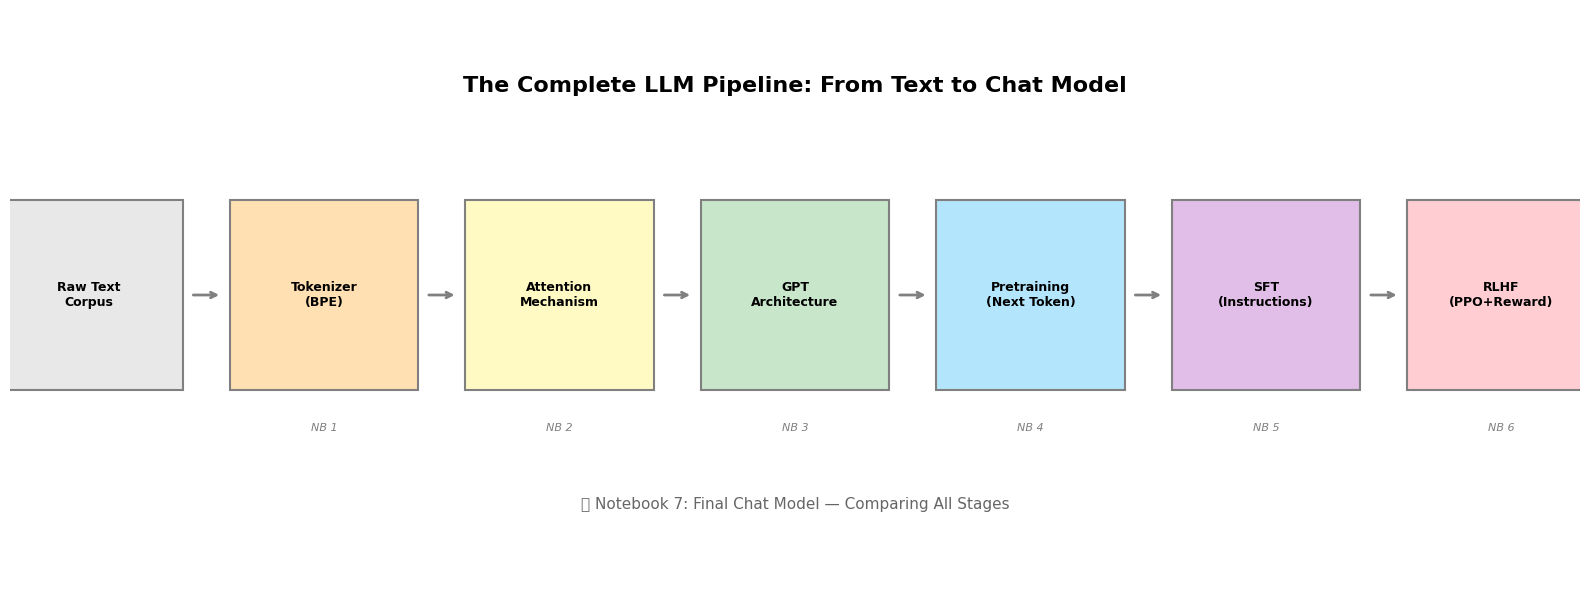

In [9]:
# ============================================================
# Pipeline summary visualization
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Define pipeline stages
stages = [
    {"x": 0.5, "label": "Raw Text\nCorpus", "color": "#E8E8E8", "nb": ""},
    {"x": 2.0, "label": "Tokenizer\n(BPE)", "color": "#FFE0B2", "nb": "NB 1"},
    {"x": 3.5, "label": "Attention\nMechanism", "color": "#FFF9C4", "nb": "NB 2"},
    {"x": 5.0, "label": "GPT\nArchitecture", "color": "#C8E6C9", "nb": "NB 3"},
    {"x": 6.5, "label": "Pretraining\n(Next Token)", "color": "#B3E5FC", "nb": "NB 4"},
    {"x": 8.0, "label": "SFT\n(Instructions)", "color": "#E1BEE7", "nb": "NB 5"},
    {"x": 9.5, "label": "RLHF\n(PPO+Reward)", "color": "#FFCDD2", "nb": "NB 6"},
]

for i, stage in enumerate(stages):
    # Box
    rect = plt.Rectangle((stage["x"] - 0.6, 2), 1.2, 2, 
                         facecolor=stage["color"], edgecolor='gray', linewidth=1.5,
                         transform=ax.transData, zorder=2)
    ax.add_patch(rect)
    
    # Label
    ax.text(stage["x"], 3, stage["label"], ha='center', va='center', 
            fontsize=9, fontweight='bold', zorder=3)
    
    # Notebook number
    if stage["nb"]:
        ax.text(stage["x"], 1.6, stage["nb"], ha='center', va='center',
                fontsize=8, color='gray', style='italic')
    
    # Arrow
    if i < len(stages) - 1:
        ax.annotate('', xy=(stages[i+1]["x"] - 0.65, 3), 
                    xytext=(stage["x"] + 0.65, 3),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2),
                    zorder=1)

# Title
ax.text(5, 5.2, 'The Complete LLM Pipeline: From Text to Chat Model', 
        ha='center', va='center', fontsize=16, fontweight='bold')

# Output label
ax.text(5, 0.8, '📘 Notebook 7: Final Chat Model — Comparing All Stages', 
        ha='center', va='center', fontsize=11, color='#666')

plt.tight_layout()
plt.savefig('full_pipeline.png', dpi=120, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


## 8. Workshop Summary & What You've Built

### 🎉 Congratulations!

You have built a **complete LLM pipeline from scratch**:

| Notebook | Topic | What You Built |
|----------|-------|----------------|
| **NB 1** | Tokenization | BPE tokenizer, sliding-window datasets |
| **NB 2** | Attention | Self-attention, causal masking, multi-head attention |
| **NB 3** | Architecture | Full GPT model with embeddings, LayerNorm, FFN |
| **NB 4** | Pretraining | Training loop, LR scheduling, text generation |
| **NB 5** | SFT | Instruction tuning with loss masking |
| **NB 6** | RLHF | Reward model (Bradley-Terry) + PPO optimization |
| **NB 7** | Chat Model | Combined system with interactive interface |

### Key Takeaways:

1. **Pretraining** gives the model language understanding
2. **SFT** teaches it to follow instructions
3. **RLHF** aligns it with human preferences
4. Each stage builds on the previous one — you can't skip steps!

### Where To Go From Here:

1. **Scale up:** Use larger datasets (TinyStories, OpenWebText) and bigger models
2. **Try DPO:** Direct Preference Optimization is simpler than PPO
3. **Add LoRA:** Parameter-efficient fine-tuning
4. **Explore quantization:** Run larger models on limited hardware
5. **Read the papers:** "Attention Is All You Need", "Language Models are Few-Shot Learners", "Training language models to follow instructions with human feedback"

---

## 🎯 Final Interview Questions

1. **Walk me through the full LLM training pipeline.**
   - Collect text data → Tokenize (BPE) → Pretrain (next-token prediction) → SFT (instruction tuning) → RLHF (reward model + PPO)

2. **Why can't you just do RLHF without pretraining/SFT?**
   - The model needs basic language understanding (pretraining) and instruction-following ability (SFT) before RLHF can meaningfully improve alignment.

3. **What's the biggest challenge in RLHF?**
   - Reward hacking (model exploits reward model), training instability (PPO is sensitive to hyperparameters), and the quality of human preference data.

4. **How would you scale this to a production model?**
   - Larger model (billions of parameters), distributed training, larger and higher-quality datasets, professional human annotators, extensive evaluation.

5. **What are alternatives to PPO for RLHF?**
   - DPO (Direct Preference Optimization), REINFORCE, reward-weighted regression, Constitutional AI (self-critique).

---

## 🔧 Troubleshooting Guide

| Problem | Solution |
|---------|----------|
| Model generates garbage | Train longer, increase data, check tokenizer |
| RLHF reward doesn't improve | Lower KL coefficient, check reward model accuracy |
| SFT model doesn't follow instructions | Check loss masking, add more instruction data |
| Out of memory | Reduce batch_size, context_length, or emb_dim |
| Training loss stuck | Check learning rate, try warmup, verify data pipeline |
| PPO training unstable | Lower learning rate, increase KL coefficient |

---

*Workshop created for Unisole Empower — Building LLMs from Scratch*
*Based on "Build a Large Language Model from Scratch" by Sebastian Raschka*
